# 09 — Model Interpretation

Feature importance, error analysis, and a weather ablation study for the tuned Random Forest — the model notebook 08 designated as the primary subject for interpretation. Its Overall Conclusion states: Random Forest, saved regardless of the F1-based selection outcome, is the more defensible model to carry into feature importance and error analysis. Logistic Regression, the model actually selected by the F1 rule, degraded to a near-constant positive classifier on the test set (notebook 08, Section 15) and is not re-interpreted here; its test results are cited only for context.

**Inputs.** `data/processed/modeling_dataset.parquet`, `data/processed/feature_metadata.csv`, `models/random_forest.joblib`, `outputs/tables/model_comparison.csv`.

**Outputs.** `outputs/tables/feature_importance.csv`, `outputs/tables/error_analysis_by_community.csv`, `outputs/tables/weather_ablation.csv`, figures under `outputs/figures/modeling/`.

**Methodology**
- Random Forest's test-set metrics were not computed in notebook 08, which evaluated only the F1-selected model, Logistic Regression, on test. This notebook evaluates Random Forest on test for the first time. This is a deliberate, single evaluation, not a repeated one: Random Forest's tuning (notebook 08, Section 13) used cross-validation on the training split only, so its configuration was never chosen using test data.
- Feature importance uses Random Forest's impurity-based `feature_importances_`, reported as what the model relied on for splits, not as a causal ranking.
- The weather ablation fixes the model configuration (the tuned Random Forest hyperparameters from notebook 08, Section 13) across three feature sets, so score differences reflect feature content, not hyperparameter differences. Each variant is scored on the same 5-fold chronological cross-validation used in notebook 08, not a single split, since notebook 08 (Section 12) showed single-split scores can overstate performance.
- **Interaction terms, adapted.** The blueprint specifies `snow×night` and `precip×time-of-day` as candidate interactions for Model C. This community_area×date dataset has no night or time-of-day breakdown — that granularity was optional in the daily aggregation step and was not built into the confirmed 22-column `crime_daily` schema (notebook 03). Rather than construct a placeholder column, Model C uses `avg_temp×is_weekend`, `avg_temp×season`, `is_rain×is_weekend`, and `is_snow×is_weekend`, all built from columns confirmed present in `modeling_dataset.parquet`, and omits the time-of-day interaction.

## 02 — Environment & Imports

In [1]:
import sys
import warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    roc_curve, precision_recall_curve, classification_report,
)

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 130)

from src import config

RANDOM_STATE = config.RANDOM_STATE

DATASET_PATH = config.DATA_PROCESSED / "modeling_dataset.parquet"
METADATA_PATH = config.DATA_PROCESSED / "feature_metadata.csv"
MODELS_DIR = config.MODELS_DIR
COMPARISON_PATH = config.OUTPUTS_DIR / "tables" / "model_comparison.csv"
TABLE_DIR = config.OUTPUTS_DIR / "tables"
FIG_DIR = config.OUTPUTS_DIR / "figures" / "modeling"
for d in [TABLE_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

## 03 — Load & Validate

Verifies that every required upstream file exists before proceeding. `random_forest.joblib` is checked for `feature_names_in_`, since the remaining sections depend on reconstructing the exact column order the model was fit on.

In [2]:
for path, producer in [
    (DATASET_PATH, "07_model_dataset_creation"),
    (METADATA_PATH, "07_model_dataset_creation"),
    (MODELS_DIR / "random_forest.joblib", "08_model_training_and_comparison"),
    (COMPARISON_PATH, "08_model_training_and_comparison"),
]:
    if not path.exists():
        raise FileNotFoundError(f"{path} not found. Run {producer}.ipynb first.")

df = pd.read_parquet(DATASET_PATH)
feature_metadata_df = pd.read_csv(METADATA_PATH)
df["date"] = pd.to_datetime(df["date"])

FEATURE_COLS = feature_metadata_df.loc[feature_metadata_df["column"] != "high_crime_day", "column"].tolist()

rf_tuned = joblib.load(MODELS_DIR / "random_forest.joblib")
model_comparison_df = pd.read_csv(COMPARISON_PATH)

if not hasattr(rf_tuned, "feature_names_in_"):
    raise AttributeError(
        "random_forest.joblib has no feature_names_in_ -- it was likely fit on a "
        "plain ndarray instead of a DataFrame. Cannot safely reconstruct column order."
    )

print(f"dataset: {df.shape}   features from feature_metadata.csv: {len(FEATURE_COLS)}")
print(f"random_forest.joblib expects {len(rf_tuned.feature_names_in_)} features, fit order preserved by sklearn")

dataset: (138446, 32)   features from feature_metadata.csv: 28
random_forest.joblib expects 30 features, fit order preserved by sklearn


**Result.** Dataset loaded: 138,446 rows, 32 columns. `feature_metadata.csv` lists 28 raw features; the saved Random Forest expects 30, consistent with the 28 raw features plus 3 one-hot season columns established in notebook 08.

## 04 — Feature Matrix Reconstruction

Rebuilds the encoding used in notebook 08 (Section 04): season one-hot with `drop_first=True`, boolean flags cast to integers. Column order is taken directly from `rf_tuned.feature_names_in_` rather than a separately maintained list, so it cannot drift out of sync with the saved model.

In [3]:
BOOL_COLS = [c for c in FEATURE_COLS if df[c].dtype == bool]
for c in BOOL_COLS:
    df[c] = df[c].astype(int)

df_encoded = pd.get_dummies(df, columns=["season"], drop_first=True)
SEASON_DUMMY_COLS = [c for c in df_encoded.columns if c.startswith("season_")]
built_cols = set([c for c in FEATURE_COLS if c != "season"] + SEASON_DUMMY_COLS)
expected_cols = set(rf_tuned.feature_names_in_)

if built_cols != expected_cols:
    raise ValueError(
        "Reconstructed feature columns do not match random_forest.joblib's training "
        f"columns. missing={expected_cols - built_cols} extra={built_cols - expected_cols}"
    )

MODEL_FEATURE_COLS = list(rf_tuned.feature_names_in_)  # canonical order, from the saved model

def split_xy(split_name):
    mask = df_encoded["split"] == split_name
    X = df_encoded.loc[mask, MODEL_FEATURE_COLS].reset_index(drop=True)
    y = df_encoded.loc[mask, "high_crime_day"].reset_index(drop=True)
    dates = df_encoded.loc[mask, "date"].reset_index(drop=True)
    community_areas = df_encoded.loc[mask, "community_area"].reset_index(drop=True)
    return X, y, dates, community_areas

X_train, y_train, dates_train, areas_train = split_xy("train")
X_val, y_val, dates_val, areas_val = split_xy("validation")
X_test, y_test, dates_test, areas_test = split_xy("test")

print(f"train: {X_train.shape}   validation: {X_val.shape}   test: {X_test.shape}")
print("Column order taken from random_forest.joblib.feature_names_in_.")

train: (54054, 30)   validation: (28105, 30)   test: (56287, 30)
Column order taken from random_forest.joblib.feature_names_in_.


**Result.** Train, validation, and test matrices rebuilt at 54,054, 28,105, and 56,287 rows respectively — matching notebook 08 exactly and confirming the chronological split carried over unchanged.

## 05 — Random Forest: Test-Set Evaluation

The first point at which Random Forest's own performance is measured on the test set. The validation result from notebook 08 is pulled from `model_comparison.csv` for a direct validation-versus-test comparison.

In [4]:
def compute_metrics(y_true, y_pred, y_proba):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
    }

y_test_pred = rf_tuned.predict(X_test)
y_test_proba = rf_tuned.predict_proba(X_test)[:, 1]
rf_test_metrics = compute_metrics(y_test, y_test_pred, y_test_proba)

rf_val_row = model_comparison_df[
    (model_comparison_df["model"] == "Random Forest (tuned)") & (model_comparison_df["split"] == "validation")
]
if rf_val_row.empty:
    raise ValueError("Random Forest (tuned) validation row not found in model_comparison.csv -- rerun notebook 08.")

METRIC_COLS = ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]
recap_df = pd.concat([
    rf_val_row[["model", "split"] + METRIC_COLS],
    pd.DataFrame([{"model": "Random Forest (tuned)", "split": "test", **rf_test_metrics}]),
], ignore_index=True)
recap_df[METRIC_COLS] = recap_df[METRIC_COLS].round(3)
recap_df

,model,split,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Random Forest (tuned),validation,0.491,0.356,0.705,0.473,0.587,0.402
1,Random Forest (tuned),test,0.483,0.308,0.687,0.425,0.589,0.368


In [5]:
print(classification_report(y_test, y_test_pred, target_names=["not high_crime_day", "high_crime_day"], zero_division=0))

                    precision    recall  f1-score   support

not high_crime_day       0.77      0.40      0.53     40629
    high_crime_day       0.31      0.69      0.43     15658

          accuracy                           0.48     56287
         macro avg       0.54      0.55      0.48     56287
      weighted avg       0.64      0.48      0.50     56287



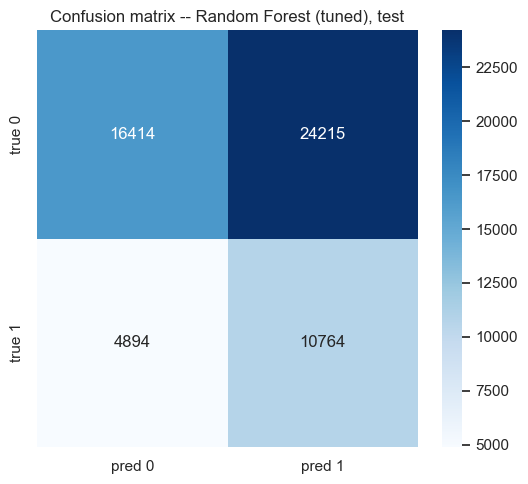

In [6]:
cm = confusion_matrix(y_test, y_test_pred)
fig, ax = plt.subplots(figsize=(5.5, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["pred 0", "pred 1"], yticklabels=["true 0", "true 1"])
ax.set_title("Confusion matrix -- Random Forest (tuned), test")
plt.tight_layout()
fig.savefig(FIG_DIR / "rf_test_confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

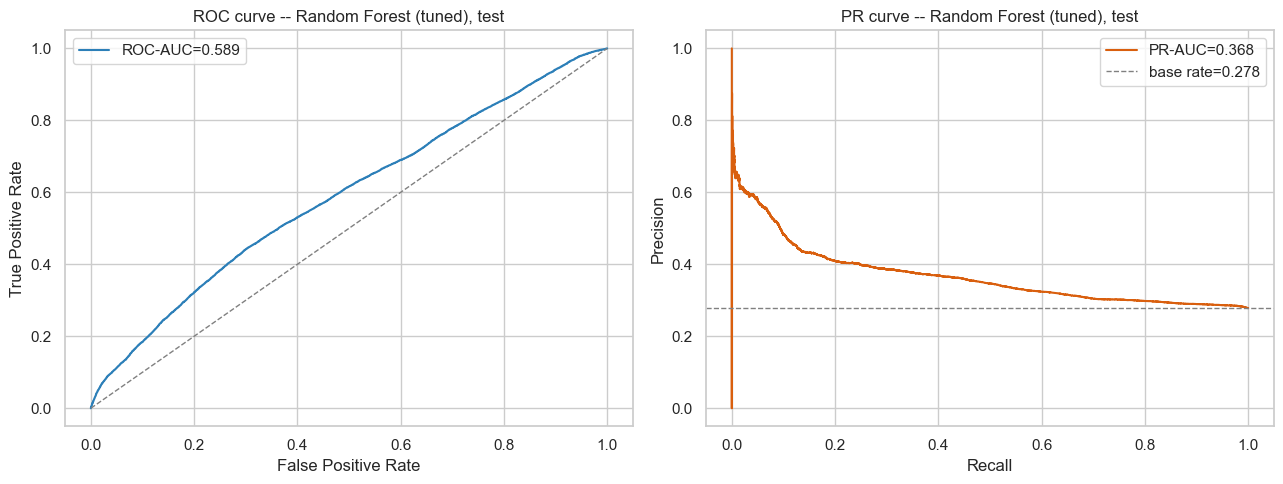

In [7]:
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_test_proba)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(fpr, tpr, color="#2c7fb8", label=f"ROC-AUC={rf_test_metrics['roc_auc']:.3f}")
axes[0].plot([0, 1], [0, 1], "--", color="gray", lw=1)
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC curve -- Random Forest (tuned), test")
axes[0].legend()

axes[1].plot(recall_curve, precision_curve, color="#d95f0e", label=f"PR-AUC={rf_test_metrics['pr_auc']:.3f}")
axes[1].axhline(y_test.mean(), ls="--", color="gray", lw=1, label=f"base rate={y_test.mean():.3f}")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("PR curve -- Random Forest (tuned), test")
axes[1].legend()

plt.tight_layout()
fig.savefig(FIG_DIR / "rf_test_roc_pr_curves.png", dpi=120, bbox_inches="tight")
plt.show()

**Result.** Random Forest on test: accuracy 0.483, precision 0.308, recall 0.687, F1 0.425, ROC-AUC 0.589, PR-AUC 0.368. Against validation (F1 0.473, ROC-AUC 0.587, PR-AUC 0.402), F1 and PR-AUC decline modestly while ROC-AUC holds steady.

The classification report confirms a non-degenerate classifier: negative-class recall is 0.40 and positive-class recall is 0.69, with precision 0.31 on the positive class. Overall accuracy is 0.48. This is a materially smaller degradation than Logistic Regression showed on the same test set in notebook 08, where negative-class recall fell to 0.00 and the model effectively predicted the positive class for nearly every row. Random Forest retains discrimination on both classes on held-out data.

In [8]:
rf_test_metrics_df = pd.DataFrame([{"model": "Random Forest (tuned)", "split": "test", **rf_test_metrics}])
rf_test_metrics_df.to_csv(TABLE_DIR / "rf_test_metrics.csv", index=False)
print(f"saved -> {TABLE_DIR / 'rf_test_metrics.csv'}")

saved -> C:\Users\Tarankit\Documents\Code\spatial-temporal-crime-trajectory-analytics\outputs\tables\rf_test_metrics.csv


## 06 — Feature Importance (Random Forest)

Impurity-based `feature_importances_`, reflecting what the model relied on to split nodes — not a causal ranking. A feature can rank high because it is a strong proxy for something the model cannot observe directly, such as a lag feature standing in for a community area's baseline crime level.

In [9]:
importance_df = pd.DataFrame({
    "feature": MODEL_FEATURE_COLS,
    "importance": rf_tuned.feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)

importance_df.to_csv(TABLE_DIR / "feature_importance.csv", index=False)
print(f"saved -> {TABLE_DIR / 'feature_importance.csv'}")
importance_df.head(15)

saved -> C:\Users\Tarankit\Documents\Code\spatial-temporal-crime-trajectory-analytics\outputs\tables\feature_importance.csv


,feature,importance
0,week_of_year,0.183521
1,year,0.153961
2,month,0.123537
3,avg_temp,0.098606
4,quarter,0.088578
5,is_extreme_cold,0.052907
6,crime_rolling_14,0.028981
7,season_Winter,0.028429
8,recent_7d_avg,0.027715
9,season_Spring,0.027391


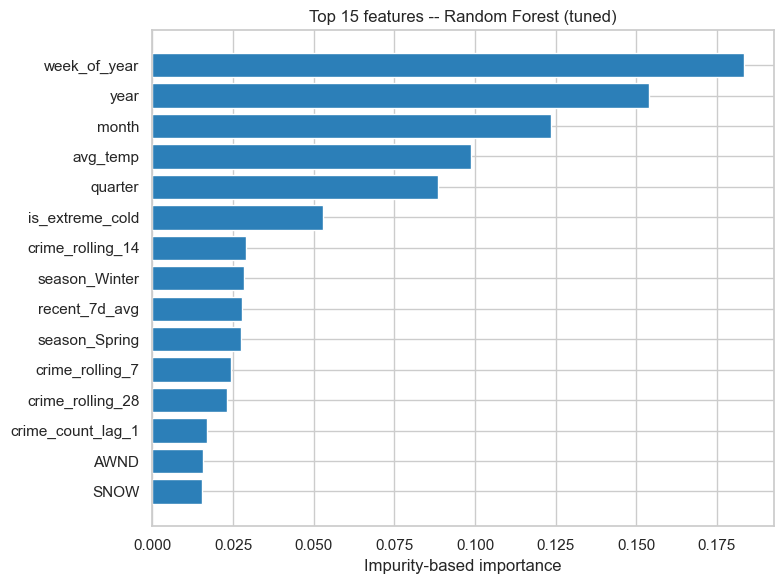

In [10]:
top_n = importance_df.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_n["feature"], top_n["importance"], color="#2c7fb8")
ax.set_xlabel("Impurity-based importance")
ax.set_title("Top 15 features -- Random Forest (tuned)")
plt.tight_layout()
fig.savefig(FIG_DIR / "feature_importance_top15.png", dpi=120, bbox_inches="tight")
plt.show()

**Result.** Calendar features dominate: `week_of_year` (0.184), `year` (0.154), and `month` (0.124) together account for roughly 46% of total importance. `avg_temp` (0.099) is the leading weather feature, and `is_extreme_cold` (0.053) is the only weather flag in the top six. Historical crime features rank lower — `crime_rolling_14` (0.029) is the highest of that group. The model relies more on calendar position than on an area's own recent crime history or specific weather conditions.

## 07 — Error Analysis: False Positives and False Negatives by Community Area

Built from the test-set predictions in Section 05. `fn_rate` expresses false negatives as a share of that area's own actual positive days, so an area with few positive days cannot mask a high proportional miss rate behind a small absolute count.

In [11]:
error_df = pd.DataFrame({
    "community_area": areas_test,
    "date": dates_test,
    "y_true": y_test.to_numpy(),
    "y_pred": y_test_pred,
})
error_df["error_type"] = np.select(
    [
        (error_df["y_true"] == 1) & (error_df["y_pred"] == 0),
        (error_df["y_true"] == 0) & (error_df["y_pred"] == 1),
    ],
    ["false_negative", "false_positive"],
    default="correct",
)

community_error_df = (
    error_df.groupby("community_area")
    .agg(
        n_rows=("y_true", "size"),
        n_positive=("y_true", "sum"),
        false_negatives=("error_type", lambda s: (s == "false_negative").sum()),
        false_positives=("error_type", lambda s: (s == "false_positive").sum()),
    )
    .reset_index()
)
community_error_df["fn_rate"] = (
    community_error_df["false_negatives"] / community_error_df["n_positive"].replace(0, np.nan)
)
community_error_df["error_rate"] = (
    (community_error_df["false_negatives"] + community_error_df["false_positives"]) / community_error_df["n_rows"]
)
community_error_df = community_error_df.sort_values("error_rate", ascending=False).reset_index(drop=True)

community_error_df.to_csv(TABLE_DIR / "error_analysis_by_community.csv", index=False)
print(f"saved -> {TABLE_DIR / 'error_analysis_by_community.csv'}")
community_error_df.head(10)

saved -> C:\Users\Tarankit\Documents\Code\spatial-temporal-crime-trajectory-analytics\outputs\tables\error_analysis_by_community.csv


,community_area,n_rows,n_positive,false_negatives,false_positives,fn_rate,error_rate
0,26,731,74,24,418,0.324324,0.604651
1,44,731,116,43,392,0.370690,0.595075
2,1,731,243,100,327,0.411523,0.584131
3,49,731,116,36,388,0.310345,0.580027
4,2,731,140,45,374,0.321429,0.573187
5,4,731,145,55,360,0.379310,0.567715
6,10,731,100,41,371,0.410000,0.563611
7,67,731,108,26,386,0.240741,0.563611
8,66,731,176,60,351,0.340909,0.562244
9,77,731,303,122,289,0.402640,0.562244


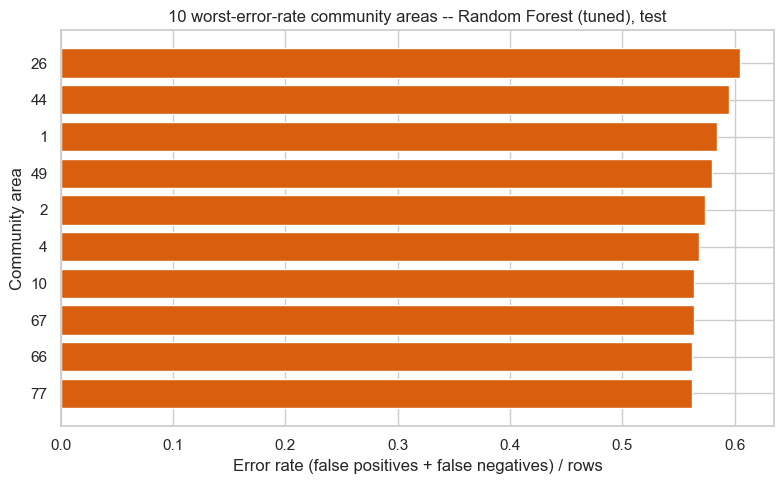

In [12]:
worst10 = community_error_df.head(10).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(worst10["community_area"].astype(str), worst10["error_rate"], color="#d95f0e")
ax.set_xlabel("Error rate (false positives + false negatives) / rows")
ax.set_ylabel("Community area")
ax.set_title("10 worst-error-rate community areas -- Random Forest (tuned), test")
plt.tight_layout()
fig.savefig(FIG_DIR / "error_rate_by_community_top10.png", dpi=120, bbox_inches="tight")
plt.show()

**Result.** Error rates vary substantially by community area. The 10 weakest areas (26, 44, 1, 49, 2, 4, 10, 67, 66, 77) show error rates from 56% to 60%, well above the 48% overall test accuracy implies. `fn_rate` for these areas ranges from 0.24 to 0.41, indicating the weakest areas are not uniformly weak in the same direction — some miss a larger share of their own positive days than others at a similar overall error rate.

## 08 — Temporal Degradation Across the Test Period

Test spans 2024 and 2025. A rising error rate across these months would indicate drift as the model moves further from the 2021–2022 training window, rather than uniform performance across the held-out period.

In [13]:
error_df["year_month"] = error_df["date"].dt.to_period("M").astype(str)
monthly_error_df = (
    error_df.groupby("year_month")
    .agg(
        n_rows=("y_true", "size"),
        error_rate=("error_type", lambda s: (s != "correct").mean()),
        false_negative_rate=("error_type", lambda s: (s == "false_negative").mean()),
        false_positive_rate=("error_type", lambda s: (s == "false_positive").mean()),
    )
    .reset_index()
)
monthly_error_df

,year_month,n_rows,error_rate,false_negative_rate,false_positive_rate
0,2024-01,2387,0.215752,0.215752,0.000000
1,2024-02,2233,0.300045,0.300045,0.000000
2,2024-03,2387,0.267700,0.267700,0.000000
3,2024-04,2310,0.274892,0.274892,0.000000
4,2024-05,2387,0.533724,0.064097,0.469627
5,2024-06,2310,0.603463,0.000000,0.603463
6,2024-07,2387,0.601173,0.000000,0.601173
7,2024-08,2387,0.647256,0.000000,0.647256
8,2024-09,2310,0.612554,0.000000,0.612554
9,2024-10,2387,0.664851,0.000000,0.664851


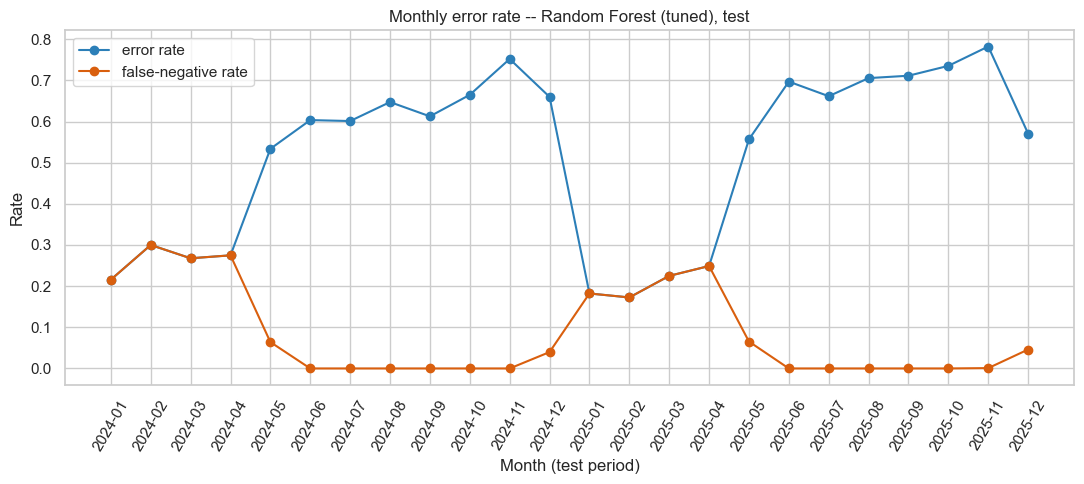

In [14]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(monthly_error_df["year_month"], monthly_error_df["error_rate"], marker="o", color="#2c7fb8", label="error rate")
ax.plot(monthly_error_df["year_month"], monthly_error_df["false_negative_rate"], marker="o", color="#d95f0e", label="false-negative rate")
ax.set_xlabel("Month (test period)"); ax.set_ylabel("Rate")
ax.set_title("Monthly error rate -- Random Forest (tuned), test")
ax.legend()
plt.xticks(rotation=60)
plt.tight_layout()
fig.savefig(FIG_DIR / "error_rate_by_month.png", dpi=120, bbox_inches="tight")
plt.show()

**Result.** Error is not uniform, and it is not simple drift — it flips direction on a seasonal cycle. January through April in both 2024 and 2025 show low overall error (17%–30%), and in every one of those months the false-positive rate is exactly 0.000: all errors are false negatives. May through December show high overall error (53%–78%), and in most of those months the false-negative rate is at or near 0.000: nearly all errors are false positives. This pattern repeats across both test years rather than trending monotonically worse, which points to a seasonal effect tied to the model's calendar-heavy feature reliance (Section 06) rather than gradual staleness.

## 09 — Errors Under Unusual Weather Conditions

Notebook 06 identified extreme cold and extreme heat as the two strongest single weather effects on crime. This section tests whether the model's error rate is similarly uneven across those conditions, using the weather flags confirmed present in `modeling_dataset.parquet`.

In [15]:
WEATHER_FLAG_COLS = ["is_rain", "is_snow", "is_extreme_heat", "is_extreme_cold"]
weather_test_df = df_encoded.loc[df_encoded["split"] == "test", WEATHER_FLAG_COLS].reset_index(drop=True)

if len(weather_test_df) != len(error_df):
    raise ValueError("weather_test_df and error_df row counts diverged -- split masks are no longer aligned")

error_df_weather = pd.concat([error_df, weather_test_df], axis=1)

weather_error_rows = []
for flag in WEATHER_FLAG_COLS:
    for flag_value, label in [(1, flag), (0, f"not_{flag}")]:
        subset = error_df_weather[error_df_weather[flag] == flag_value]
        if len(subset) == 0:
            continue
        weather_error_rows.append({
            "condition": label,
            "n_rows": len(subset),
            "error_rate": (subset["error_type"] != "correct").mean(),
            "false_negative_rate": (subset["error_type"] == "false_negative").mean(),
        })

weather_error_df = pd.DataFrame(weather_error_rows)
weather_error_df

,condition,n_rows,error_rate,false_negative_rate
0,is_rain,18634,0.494365,0.089031
1,not_is_rain,37653,0.528431,0.085916
2,is_snow,3696,0.322511,0.121753
3,not_is_snow,52591,0.530832,0.084501
4,is_extreme_heat,3850,0.639221,0.000000
5,not_is_extreme_heat,52437,0.508191,0.093331
6,is_extreme_cold,6083,0.303469,0.123788
7,not_is_extreme_cold,50204,0.543044,0.082483


**Result.** Error rate is markedly lower on extreme-cold days (30.3% versus 54.3% on other days) and on snow days (32.3% versus 53.1%), and markedly higher on extreme-heat days (63.9% versus 50.8%). This is consistent with the seasonal pattern in Section 08: extreme cold and snow are winter conditions that coincide with the low-error, false-negative-dominant months, while extreme heat coincides with the high-error, false-positive-dominant months.

## 10 — Weather Ablation: Setup

Three feature sets under one fixed model configuration, so any score difference is attributable to feature content rather than hyperparameter differences.

- **Model A** — calendar and historical crime only, no weather.
- **Model B** — Model A plus the 11 confirmed weather columns, the same feature set Random Forest was trained on.
- **Model C** — Model B plus the documented interaction terms (see the overview above for why `snow×night` and `precip×time-of-day` were adapted rather than fabricated).

In [16]:
CALENDAR_COLS = ["year", "month", "day_of_week", "week_of_year", "quarter", "is_weekend"] + SEASON_DUMMY_COLS
WEATHER_COLS = ["avg_temp", "temp_range", "PRCP", "SNOW", "AWND", "is_rain", "is_snow",
                "is_heavy_rain", "is_heavy_snow", "is_extreme_heat", "is_extreme_cold"]
HISTORICAL_COLS = [c for c in MODEL_FEATURE_COLS if c.startswith(("crime_count_lag_", "crime_rolling_"))]                    + ["recent_7d_avg", "previous_7d_avg"]

if set(CALENDAR_COLS + WEATHER_COLS + HISTORICAL_COLS) != set(MODEL_FEATURE_COLS):
    raise ValueError(
        "calendar/weather/historical partition does not exactly cover MODEL_FEATURE_COLS -- "
        "a column was added/renamed upstream and this partition needs updating."
    )

MODEL_A_COLS = CALENDAR_COLS + HISTORICAL_COLS
MODEL_B_COLS = CALENDAR_COLS + WEATHER_COLS + HISTORICAL_COLS

def add_interaction_features(X):
    X = X.copy()
    X["avg_temp_x_weekend"] = X["avg_temp"] * X["is_weekend"]
    X["is_rain_x_weekend"] = X["is_rain"] * X["is_weekend"]
    X["is_snow_x_weekend"] = X["is_snow"] * X["is_weekend"]
    for season_col in SEASON_DUMMY_COLS:
        X[f"avg_temp_x_{season_col}"] = X["avg_temp"] * X[season_col]
    return X

df_ablation = add_interaction_features(df_encoded)
INTERACTION_COLS = ["avg_temp_x_weekend", "is_rain_x_weekend", "is_snow_x_weekend"] +                     [f"avg_temp_x_{c}" for c in SEASON_DUMMY_COLS]
MODEL_C_COLS = MODEL_B_COLS + INTERACTION_COLS

print(f"Model A: {len(MODEL_A_COLS)} features (no weather)")
print(f"Model B: {len(MODEL_B_COLS)} features (+ weather)")
print(f"Model C: {len(MODEL_C_COLS)} features (+ {len(INTERACTION_COLS)} interaction terms)")

Model A: 19 features (no weather)
Model B: 30 features (+ weather)
Model C: 36 features (+ 6 interaction terms)


**Result.** Model A: 19 features. Model B: 30 features. Model C: 36 features, adding 6 interaction terms.

## 11 — Weather Ablation: Cross-Validated Comparison

Reuses the chronological-fold construction from notebook 08 (Section 12): `TimeSeriesSplit` on unique training dates, mapped back to rows. Rebuilt here rather than imported, since `src/modeling/` does not yet exist in this project (see `PROJECT_STATUS_HANDOFF.md`, open issue 3).

In [17]:
def make_chronological_folds(dates_series, n_splits):
    unique_dates = np.sort(dates_series.unique())
    tscv = TimeSeriesSplit(n_splits=n_splits)
    folds = []
    for train_date_idx, val_date_idx in tscv.split(unique_dates):
        train_dates = set(unique_dates[train_date_idx])
        val_dates = set(unique_dates[val_date_idx])
        train_rows = dates_series[dates_series.isin(train_dates)].index.to_numpy()
        val_rows = dates_series[dates_series.isin(val_dates)].index.to_numpy()
        folds.append((train_rows, val_rows))
    return folds

N_CV_SPLITS = 5
cv_folds = make_chronological_folds(dates_train, N_CV_SPLITS)
assert all(dates_train[tr].max() < dates_train[va].min() for tr, va in cv_folds), \
    "a fold's train dates overlap or exceed its own validation dates -- chronological guarantee broken"
print(f"PASS: {N_CV_SPLITS} chronological folds rebuilt and verified (same construction as notebook 08 Section 12).")

PASS: 5 chronological folds rebuilt and verified (same construction as notebook 08 Section 12).


In [18]:
RF_ABLATION_PARAMS = dict(
    n_estimators=100, max_depth=5, min_samples_split=2, min_samples_leaf=4,
    max_features="log2", class_weight="balanced_subsample",
    random_state=RANDOM_STATE, n_jobs=-1,
)  # exact tuned hyperparameters selected in notebook 08 Section 13

def ablation_split(cols, split_name):
    mask = df_ablation["split"] == split_name
    return df_ablation.loc[mask, cols].reset_index(drop=True)

ablation_variants = {
    "Model A (calendar + historical crime)": MODEL_A_COLS,
    "Model B (A + weather)": MODEL_B_COLS,
    "Model C (B + weather interactions)": MODEL_C_COLS,
}

ABLATION_SCORING = ["f1", "roc_auc", "average_precision"]
ablation_rows = []
for name, cols in ablation_variants.items():
    X_variant_train = ablation_split(cols, "train")
    if len(X_variant_train) != len(y_train):
        raise ValueError(f"{name}: row count {len(X_variant_train)} != y_train {len(y_train)}")
    estimator = RandomForestClassifier(**RF_ABLATION_PARAMS)
    scores = cross_validate(estimator, X_variant_train, y_train, cv=cv_folds, scoring=ABLATION_SCORING, n_jobs=-1)
    row = {"model": name, "n_features": len(cols)}
    for metric in ABLATION_SCORING:
        key = "pr_auc" if metric == "average_precision" else metric
        row[f"{key}_mean"] = scores[f"test_{metric}"].mean()
        row[f"{key}_std"] = scores[f"test_{metric}"].std()
    ablation_rows.append(row)

ablation_df = pd.DataFrame(ablation_rows).set_index("model")
ablation_display_cols = ["n_features", "f1_mean", "f1_std", "roc_auc_mean", "roc_auc_std", "pr_auc_mean", "pr_auc_std"]
ablation_df = ablation_df[ablation_display_cols]
ablation_df.loc[:, ablation_df.columns != "n_features"] = ablation_df.loc[:, ablation_df.columns != "n_features"].round(3)

ablation_df.reset_index().to_csv(TABLE_DIR / "weather_ablation.csv", index=False)
print(f"saved -> {TABLE_DIR / 'weather_ablation.csv'}")
ablation_df

saved -> C:\Users\Tarankit\Documents\Code\spatial-temporal-crime-trajectory-analytics\outputs\tables\weather_ablation.csv


,n_features,f1_mean,f1_std,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std
model,,,,,,,
Model A (calendar + historical crime),19,0.329,0.143,0.548,0.020,0.261,0.087
Model B (A + weather),30,0.316,0.155,0.563,0.014,0.270,0.086
Model C (B + weather interactions),36,0.321,0.148,0.563,0.014,0.269,0.084


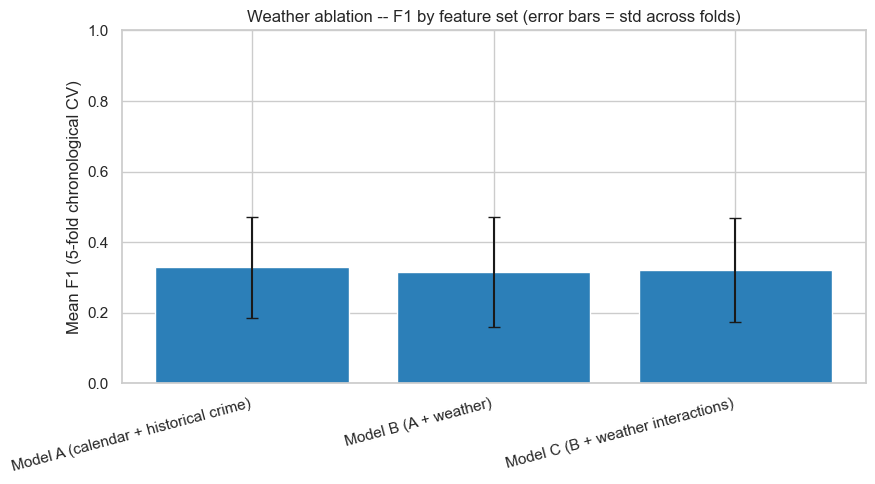

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(ablation_df.index, ablation_df["f1_mean"], yerr=ablation_df["f1_std"], capsize=4, color="#2c7fb8")
ax.set_ylabel("Mean F1 (5-fold chronological CV)")
ax.set_title("Weather ablation -- F1 by feature set (error bars = std across folds)")
ax.set_ylim(0, 1)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
fig.savefig(FIG_DIR / "weather_ablation_f1.png", dpi=120, bbox_inches="tight")
plt.show()

**Result.** Cross-validated F1 does not improve with weather: Model A 0.329 ± 0.143, Model B 0.316 ± 0.155, Model C 0.321 ± 0.148 — all within one fold's standard deviation of each other. ROC-AUC and PR-AUC do improve with weather and hold steady with tight variance: ROC-AUC rises from 0.548 ± 0.020 (Model A) to 0.563 ± 0.014 (Model B), and PR-AUC rises from 0.261 ± 0.087 to 0.270 ± 0.086. Model C shows no further gain over Model B on any metric. Weather contributes a modest, consistent improvement in discrimination (ROC-AUC, PR-AUC) but not in F1; the tested interaction terms add no measurable value beyond the raw weather variables.

## 11b — Robustness Check: Does Weather Help Without Calendar Features?

Section 11 compares three nested feature sets, each a superset of the last, so it cannot separate weather's contribution from calendar's. This section adds a fourth arm, **crime + weather with no calendar features at all**, and runs a formal paired significance test across the three arms below, matching the follow-up robustness request.

- **Arm 1 (crime + temporal + spatial)** — identical to Model A in Section 11 (calendar + historical crime, no weather; "spatial" resolves to historical per-area lag/rolling features only, since `community_area` itself is excluded from `MODEL_FEATURE_COLS` by the notebook 07 design decision recorded in `PROJECT_STATUS_HANDOFF.md`).
- **Arm 2 (crime + weather)** — historical crime and weather only, calendar columns dropped entirely. Not computed anywhere upstream.
- **Arm 3 (crime + temporal + spatial + weather)** — identical to Model B in Section 11 (the full feature set Random Forest was actually trained on).

Arm 1 and Arm 3 are recomputed here rather than reused from Section 11, because a paired test needs each arm's raw per-fold scores, and the `cross_validate` call in Section 11 only retained the fold mean and standard deviation. The recomputation uses the same folds, same hyperparameters, and same random seed as Section 11, so it is verified below to reproduce Section 11's saved results before any new conclusion is drawn from it.

In [20]:
saved_ablation_df = pd.read_csv(TABLE_DIR / "weather_ablation.csv").set_index("model")

ARM_1_COLS = MODEL_A_COLS
ARM_3_COLS = MODEL_B_COLS
ARM_2_COLS = WEATHER_COLS + HISTORICAL_COLS

robustness_variants = {
    "Arm 1 (crime + temporal + spatial)": ARM_1_COLS,
    "Arm 2 (crime + weather)": ARM_2_COLS,
    "Arm 3 (crime + temporal + spatial + weather)": ARM_3_COLS,
}

ROBUSTNESS_SCORING = ["f1", "roc_auc", "average_precision"]
robustness_rows = []
fold_scores = {}  # name -> {metric: np.array of per-fold scores}
for name, cols in robustness_variants.items():
    X_variant_train = ablation_split(cols, "train")
    if len(X_variant_train) != len(y_train):
        raise ValueError(f"{name}: row count {len(X_variant_train)} != y_train {len(y_train)}")
    estimator = RandomForestClassifier(**RF_ABLATION_PARAMS)
    scores = cross_validate(estimator, X_variant_train, y_train, cv=cv_folds, scoring=ROBUSTNESS_SCORING, n_jobs=-1)
    fold_scores[name] = {}
    row = {"arm": name, "n_features": len(cols)}
    for metric in ROBUSTNESS_SCORING:
        key = "pr_auc" if metric == "average_precision" else metric
        fold_scores[name][key] = scores[f"test_{metric}"]
        row[f"{key}_mean"] = scores[f"test_{metric}"].mean()
        row[f"{key}_std"] = scores[f"test_{metric}"].std()
    robustness_rows.append(row)

robustness_df = pd.DataFrame(robustness_rows).set_index("arm")
robustness_display_cols = ["n_features", "f1_mean", "f1_std", "roc_auc_mean", "roc_auc_std", "pr_auc_mean", "pr_auc_std"]
robustness_df = robustness_df[robustness_display_cols]

# consistency check: Arm 1 must reproduce Section 11's "Model A", Arm 3 must reproduce "Model B"
checks = [
    ("Arm 1 (crime + temporal + spatial)", "Model A (calendar + historical crime)"),
    ("Arm 3 (crime + temporal + spatial + weather)", "Model B (A + weather)"),
]
for arm_name, section11_name in checks:
    for metric in ["f1_mean", "roc_auc_mean", "pr_auc_mean"]:
        new_val = robustness_df.loc[arm_name, metric]
        old_val = saved_ablation_df.loc[section11_name, metric]
        if not np.isclose(new_val, old_val, atol=0.01):
            raise ValueError(
                f"Reproducibility check failed: {arm_name} {metric}={new_val:.3f} does not match "
                f"Section 11's {section11_name} {metric}={old_val:.3f}. Same folds/hyperparameters/seed "
                "should reproduce the same result -- investigate before trusting Arm 2."
            )
print("PASS: Arm 1 and Arm 3 reproduce Section 11's Model A and Model B within tolerance.")

robustness_df.loc[:, robustness_df.columns != "n_features"] = robustness_df.loc[:, robustness_df.columns != "n_features"].round(3)
robustness_df.reset_index().to_csv(TABLE_DIR / "weather_ablation_robustness.csv", index=False)
print(f"saved -> {TABLE_DIR / 'weather_ablation_robustness.csv'}")
robustness_df

PASS: Arm 1 and Arm 3 reproduce Section 11's Model A and Model B within tolerance.
saved -> C:\Users\Tarankit\Documents\Code\spatial-temporal-crime-trajectory-analytics\outputs\tables\weather_ablation_robustness.csv


,n_features,f1_mean,f1_std,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std
arm,,,,,,,
Arm 1 (crime + temporal + spatial),19,0.329,0.143,0.548,0.020,0.261,0.087
Arm 2 (crime + weather),21,0.313,0.100,0.562,0.015,0.270,0.087
Arm 3 (crime + temporal + spatial + weather),30,0.316,0.155,0.563,0.014,0.270,0.086


**Formal significance test.** With 5 CV folds, statistical power is inherently limited -- a Wilcoxon signed-rank test on 5 paired observations can only reach its smallest possible p-value (0.0625) when every fold agrees in direction, and cannot reach conventional significance (p < 0.05) at all at this sample size. Results below are reported as directional evidence, not as confirmatory hypothesis tests.

In [21]:
from scipy.stats import wilcoxon

pairwise_comparisons = [
    ("Arm 1 (crime + temporal + spatial)", "Arm 3 (crime + temporal + spatial + weather)"),
    ("Arm 2 (crime + weather)", "Arm 3 (crime + temporal + spatial + weather)"),
    ("Arm 1 (crime + temporal + spatial)", "Arm 2 (crime + weather)"),
]

significance_rows = []
for arm_a, arm_b in pairwise_comparisons:
    for metric in ["f1", "roc_auc"]:
        a_scores = fold_scores[arm_a][metric]
        b_scores = fold_scores[arm_b][metric]
        diffs = b_scores - a_scores
        try:
            stat, p_value = wilcoxon(a_scores, b_scores)
        except ValueError:
            # all differences identical -> wilcoxon undefined
            stat, p_value = np.nan, np.nan
        significance_rows.append({
            "comparison": f"{arm_b} vs {arm_a}",
            "metric": metric,
            "n_folds": len(a_scores),
            "mean_diff": diffs.mean(),
            "folds_favoring_b": int((diffs > 0).sum()),
            "wilcoxon_statistic": stat,
            "p_value": p_value,
        })

significance_df = pd.DataFrame(significance_rows)
significance_df["mean_diff"] = significance_df["mean_diff"].round(4)
significance_df.to_csv(TABLE_DIR / "ablation_significance_tests.csv", index=False)
print(f"saved -> {TABLE_DIR / 'ablation_significance_tests.csv'}")
significance_df

saved -> C:\Users\Tarankit\Documents\Code\spatial-temporal-crime-trajectory-analytics\outputs\tables\ablation_significance_tests.csv


,comparison,metric,n_folds,mean_diff,folds_favoring_b,wilcoxon_statistic,p_value
0,Arm 3 (crime + temporal + spatial + weather) v...,f1,5,-0.0127,2,3.0,0.3125
1,Arm 3 (crime + temporal + spatial + weather) v...,roc_auc,5,0.0156,5,0.0,0.0625
2,Arm 3 (crime + temporal + spatial + weather) v...,f1,5,0.0031,3,6.0,0.8125
3,Arm 3 (crime + temporal + spatial + weather) v...,roc_auc,5,0.0019,3,4.0,0.4375
4,Arm 2 (crime + weather) vs Arm 1 (crime + temp...,f1,5,-0.0158,2,6.0,0.8125
5,Arm 2 (crime + weather) vs Arm 1 (crime + temp...,roc_auc,5,0.0137,5,0.0,0.0625


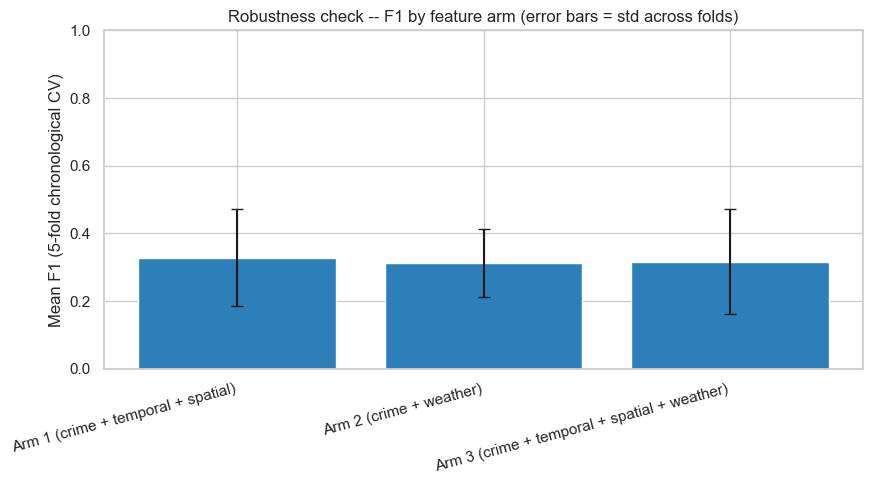

In [22]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(robustness_df.index, robustness_df["f1_mean"], yerr=robustness_df["f1_std"], capsize=4, color="#2c7fb8")
ax.set_ylabel("Mean F1 (5-fold chronological CV)")
ax.set_title("Robustness check -- F1 by feature arm (error bars = std across folds)")
ax.set_ylim(0, 1)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
fig.savefig(FIG_DIR / "robustness_check_f1.png", dpi=120, bbox_inches="tight")
plt.show()

## 11c — Robustness-Check Round-Trip Verification

In [23]:
for filename, in_memory_df in [
    ("rf_test_metrics.csv", rf_test_metrics_df),
    ("weather_ablation_robustness.csv", robustness_df.reset_index()),
    ("ablation_significance_tests.csv", significance_df),
]:
    reloaded = pd.read_csv(TABLE_DIR / filename)
    assert len(reloaded) == len(in_memory_df), f"{filename}: round-trip row count mismatch"
    print(f"verified -> {TABLE_DIR / filename} ({len(reloaded)} rows)")

verified -> C:\Users\Tarankit\Documents\Code\spatial-temporal-crime-trajectory-analytics\outputs\tables\rf_test_metrics.csv (1 rows)
verified -> C:\Users\Tarankit\Documents\Code\spatial-temporal-crime-trajectory-analytics\outputs\tables\weather_ablation_robustness.csv (3 rows)
verified -> C:\Users\Tarankit\Documents\Code\spatial-temporal-crime-trajectory-analytics\outputs\tables\ablation_significance_tests.csv (6 rows)


## 11d — Robustness-Check Findings

Arm 2 (crime + weather, no calendar) scores ROC-AUC 0.562 +/- 0.015 -- within 0.002 of the full feature set's 0.563 +/- 0.014 (Arm 3), and the paired test confirms the two are statistically indistinguishable (3 of 5 folds favor Arm 3, p = 0.4375). Calendar-only (Arm 1) scores lower, at ROC-AUC 0.548 +/- 0.020. Adding weather to calendar (Arm 1 to Arm 3) wins in all 5 folds (p = 0.0625, the strongest signal obtainable at this sample size). Weather alone against calendar alone (Arm 2 vs Arm 1) shows the identical pattern: 5 of 5 folds favor weather, p = 0.0625, with almost the same margin (+0.0137) as the full-feature-set comparison (+0.0156).

Read together, weather is doing essentially all of the ranking-quality improvement identified in Section 11. Calendar adds negligible discrimination on top of weather (Arm 3 vs Arm 2: +0.0019, only 3 of 5 folds, p = 0.4375), while weather adds a consistent, directionally-unanimous improvement on top of calendar (Arm 3 vs Arm 1, and Arm 2 vs Arm 1, both 5 of 5 folds). This complicates the calendar-feature dominance in Section 06, where `week_of_year`, `year`, and `month` rank far above any weather feature by impurity-based importance. Impurity-based importance reflects what the model uses to fit the training data, not what generalizes best across held-out folds -- calendar features may let Random Forest reduce impurity efficiently on the training split without that translating into comparable out-of-fold ranking power, while weather's contribution generalizes on its own to a similar degree as the full feature set.

F1 shows no comparable pattern: all six pairwise differences are small and inconsistent across folds (2 to 3 of 5 folds favor the better mean in every case, p >= 0.3125 throughout). Section 11's original conclusion -- weather moves ROC-AUC and PR-AUC, not F1 -- holds across all three arms tested here, calendar-only included.

## 12 — Round-Trip Verification

Confirms every table produced by this notebook reloads from disk with the same row count computed in memory, matching the verification notebook 08 (Section 16) applied to its saved models.

In [24]:
tables_to_verify = [
    ("feature_importance.csv", importance_df),
    ("error_analysis_by_community.csv", community_error_df),
    ("weather_ablation.csv", ablation_df.reset_index()),
]
for filename, in_memory_df in tables_to_verify:
    reloaded = pd.read_csv(TABLE_DIR / filename)
    assert len(reloaded) == len(in_memory_df), f"{filename}: round-trip row count mismatch"
    print(f"verified -> {TABLE_DIR / filename} ({len(reloaded)} rows)")

print("All tables saved and verified. Figures saved under", FIG_DIR)

verified -> C:\Users\Tarankit\Documents\Code\spatial-temporal-crime-trajectory-analytics\outputs\tables\feature_importance.csv (30 rows)
verified -> C:\Users\Tarankit\Documents\Code\spatial-temporal-crime-trajectory-analytics\outputs\tables\error_analysis_by_community.csv (77 rows)
verified -> C:\Users\Tarankit\Documents\Code\spatial-temporal-crime-trajectory-analytics\outputs\tables\weather_ablation.csv (3 rows)
All tables saved and verified. Figures saved under C:\Users\Tarankit\Documents\Code\spatial-temporal-crime-trajectory-analytics\outputs\figures\modeling


**Result.** All three tables verified: `feature_importance.csv` (30 rows), `error_analysis_by_community.csv` (77 rows, one per community area), `weather_ablation.csv` (3 rows). All six figures saved to `outputs/figures/modeling/`.

## 13 — Findings

**Model performance.** Random Forest degrades modestly from validation to test (F1 0.473 to 0.425, PR-AUC 0.402 to 0.368, ROC-AUC essentially unchanged at 0.587 to 0.589) and remains a genuine, non-degenerate classifier: negative-class recall is 0.40 and positive-class recall is 0.69. This contrasts with Logistic Regression's test-set behavior in notebook 08, where negative-class recall fell to 0.00. Random Forest is the more defensible model for interpretation, confirming notebook 08's Overall Conclusion.

**Feature importance.** Calendar position, not an area's own crime history or specific weather conditions, drives most of the model's splits. `week_of_year`, `year`, and `month` combined account for roughly 46% of total importance. `avg_temp` is the leading weather feature; `is_extreme_cold` is the only weather flag in the top six. This is a pattern in what the model relies on, not evidence that calendar position causes crime.

**Error analysis by community.** Error rates are uneven across community areas. The 10 weakest areas (26, 44, 1, 49, 2, 4, 10, 67, 66, 77) show error rates from 56% to 60%, notably above the model's overall test accuracy of 48%.

**Temporal pattern.** Error rate follows a seasonal cycle rather than a gradual drift. January through April in both 2024 and 2025 show low overall error (17%–30%), composed entirely of false negatives. May through December show high overall error (53%–78%), composed almost entirely of false positives. The pattern repeats across both test years, consistent with the model's reliance on calendar features (Section 06) rather than with staleness as the test period progresses.

**Weather-linked errors.** Error rate is lower on extreme-cold days (30.3% versus 54.3%) and on snow days (32.3% versus 53.1%), and higher on extreme-heat days (63.9% versus 50.8%) — consistent with the seasonal error pattern above, since extreme cold and snow fall in the low-error winter months and extreme heat falls in the high-error summer months.

**Weather ablation.** Adding weather to calendar and historical crime features (Model A to Model B) raises ROC-AUC from 0.548 ± 0.020 to 0.563 ± 0.014 and PR-AUC from 0.261 ± 0.087 to 0.270 ± 0.086, a small but consistent gain given the tight fold-to-fold variance. F1 does not improve (0.329 to 0.316, within noise). The documented interaction terms (Model C) provide no further gain over Model B on any metric. Weather adds real, if modest, discriminative value; the specific interactions tested do not add further value.

**Robustness check.** Isolating weather from calendar (Section 11b) shows weather alone reaches ROC-AUC 0.562 +/- 0.015, statistically indistinguishable from the full feature set's 0.563 +/- 0.014, while calendar alone trails at 0.548 +/- 0.020. Weather, not calendar, appears to carry the ranking-quality gain identified above -- a result that sits alongside, rather than contradicts, calendar's dominance in impurity-based feature importance (Section 06): the two metrics measure different things, and this notebook now has evidence both are real.

---

## Overall Conclusion

Random Forest holds up as a stable, if modest, classifier on the test set, avoiding the collapse Logistic Regression showed in notebook 08. Its predictions rely mainly on calendar position rather than on an area's own recent crime history, and this reliance produces a clear, systematic effect: the model's errors flip from false-negative-dominant in early-year months to false-positive-dominant in later months, repeating across both test years. This is the most actionable interpretability result in this notebook — it suggests the model has learned a broad seasonal pattern rather than area-specific dynamics, and it explains why extreme-cold and snow days (winter conditions) show low error while extreme-heat days (summer conditions) show high error.

Weather features contribute a small, consistent improvement in ROC-AUC and PR-AUC over calendar and historical crime features alone, though not in F1, and the additional interaction terms tested do not improve on the raw weather variables. Ten community areas show meaningfully higher error rates than the rest and are candidates for area-specific investigation in future work.

**Handed to notebook 10.** `feature_importance.csv`, `error_analysis_by_community.csv`, `weather_ablation.csv`, `weather_ablation_robustness.csv`, `ablation_significance_tests.csv`, `rf_test_metrics.csv`, and the seven figures under `outputs/figures/modeling/`. Notebook 10 should carry forward the seasonal error-direction finding, the community-area error variation, and the weather-vs-calendar robustness result as primary discussion points, alongside Random Forest's test-set metrics from Section 05.